# LAB 11: Implement Ensemble Learning using Suitable Dataset

 NAME : RAKSHITHA V S

 ROLL NO: 2348448

## Aim: The aim is to implement Ensemble Learning using Suitable Dataset

## Construct a dataset (Data Collection)

#### Data Collection: The dataset is collected from Kaggle which is Heart Failure Prediction. The different featured columns of this dataset are:
#### Age: age of the patient [years]
#### Sex: sex of the patient [M: Male, F: Female]
#### ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
#### RestingBP: resting blood pressure [mm Hg]
#### Cholesterol: serum cholesterol [mm/dl]
#### FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
#### RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
#### MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
#### ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
#### Oldpeak: oldpeak = ST [Numeric value measured in depression]
#### ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
#### HeartDisease: output class [1: heart disease, 0: Normal]

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn import metrics
from sklearn.manifold import MDS
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score, classification_report, confusion_matrix
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_predict

## 1) Loading the dataset.

In [5]:
data=pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/heart_.csv")
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2) Display basic information about the dataset like the number of samples, features, data types, etc.

In [ ]:
#Basic information about the dataset like the number of samples, features, data types, etc.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
#Univariate Analysis:
#For numerical variables:
#Basic descriptive statistics
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
print(data.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [ ]:
for i in range(data.shape[1]):
    print(data.iloc[:,i].unique())

[40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]
['M' 'F']
['ATA' 'NAP' 'ASY' 'TA']
[140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164]
[289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161 228 292 388 166 247 331 341 243 279 198 249 168 603
 159 190 185 290 212 231 222 235 320 187 266 287 404 312 251 328 285 280
 192 193 308 219 257 132 22

## 3) Display the first few rows to understand the structure and format of the data.

In [ ]:
print("\nFirst few rows:")
print(data.head())


First few rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


## 4) Univariate Analysis:
### a. For numerical variables:
#### i. Calculate basic descriptive statistics (mean, median, mode, standard deviation, min, max, quartiles, etc.).

In [ ]:
Heart = data['HeartDisease']
mean = np.mean(Heart)
mode = np.nan
std_dev = np.std(Heart)
minimum = np.min(Heart)
maximum = np.max(Heart)
q1 = np.percentile(Heart, 25)
q3 = np.percentile(Heart, 75)

print("Descriptive Statistics:")
print(f"Mean: {mean:.2f}")
print(f"Mode: {mode}")
print(f"Standard Deviation: {std_dev:.2f}")
print(f"Maximum: {maximum:.2f}")
print(f"Minimum: {minimum:.2f}")
print(f"1st Quartile (Q1): {q1:.2f}")
print(f"3rd Quartile (Q3): {q3:.2f}")

Descriptive Statistics:
Mean: 0.55
Mode: nan
Standard Deviation: 0.50
Maximum: 1.00
Minimum: 0.00
1st Quartile (Q1): 0.00
3rd Quartile (Q3): 1.00


#### ii. Visualize the distribution using histograms, kernel density plots, or box plots.

<Figure size 1200x800 with 0 Axes>

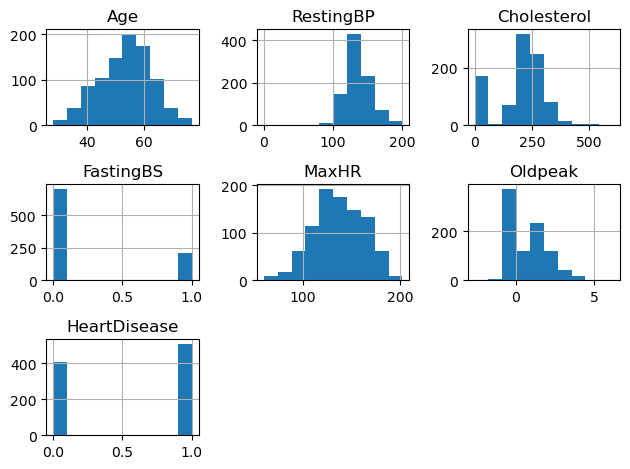

In [ ]:
# hisograms
plt.figure(figsize=(12, 8))
data.hist()
plt.tight_layout()
plt.show()

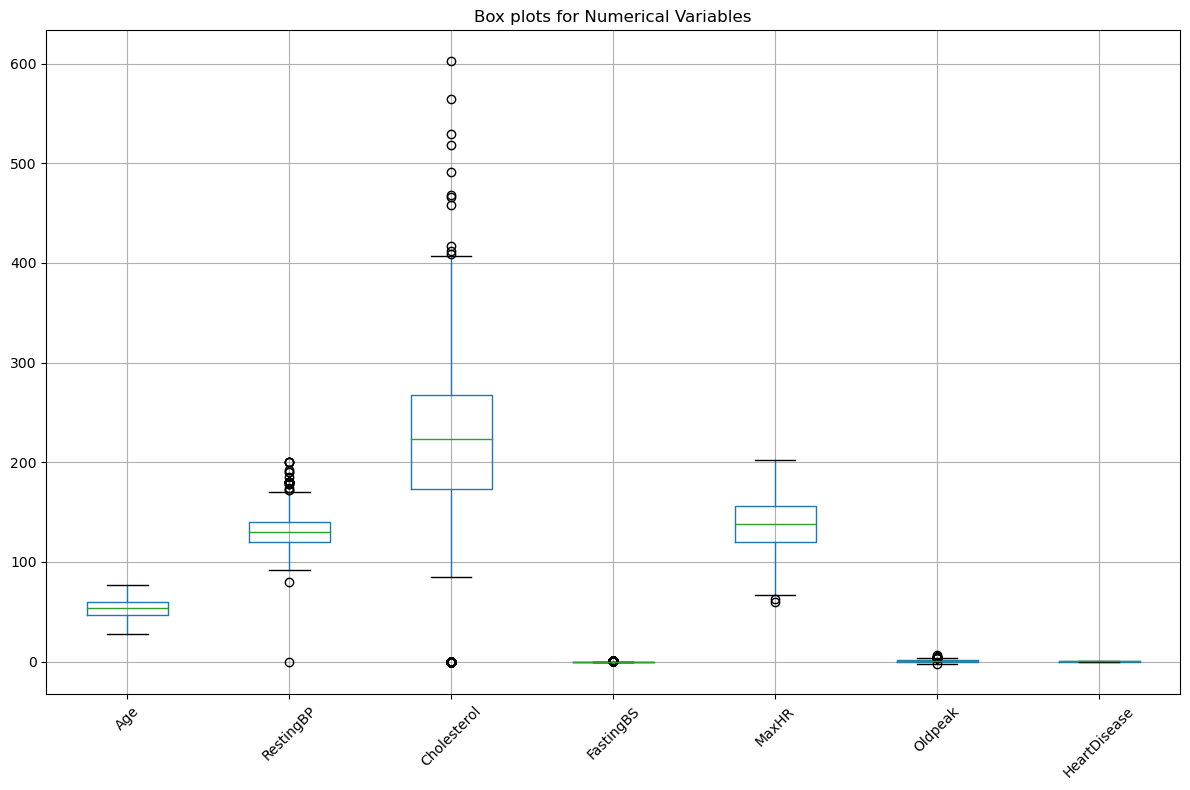

In [ ]:
# Box plots for numerical variables
plt.figure(figsize=(12, 8))
data.boxplot()
plt.title('Box plots for Numerical Variables')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

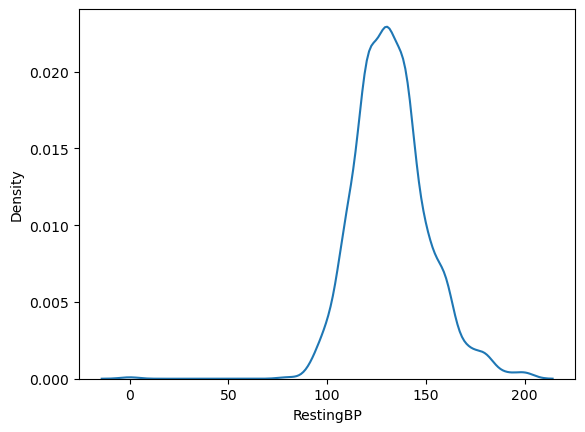

In [ ]:
#kde
sns.kdeplot(data['RestingBP']);

### b. For categorical variables:
#### i. Display frequency tables showing counts and percentages.

In [ ]:
for column in data.select_dtypes(include='object').columns:
    print("\nFrequency table for", column)
    print(data[column].value_counts(normalize=True))


Frequency table for Sex
M    0.78976
F    0.21024
Name: Sex, dtype: float64

Frequency table for ChestPainType
ASY    0.540305
NAP    0.221133
ATA    0.188453
TA     0.050109
Name: ChestPainType, dtype: float64

Frequency table for RestingECG
Normal    0.601307
LVH       0.204793
ST        0.193900
Name: RestingECG, dtype: float64

Frequency table for ExerciseAngina
N    0.595861
Y    0.404139
Name: ExerciseAngina, dtype: float64

Frequency table for ST_Slope
Flat    0.501089
Up      0.430283
Down    0.068627
Name: ST_Slope, dtype: float64


#### ii. Visualize using bar plots.

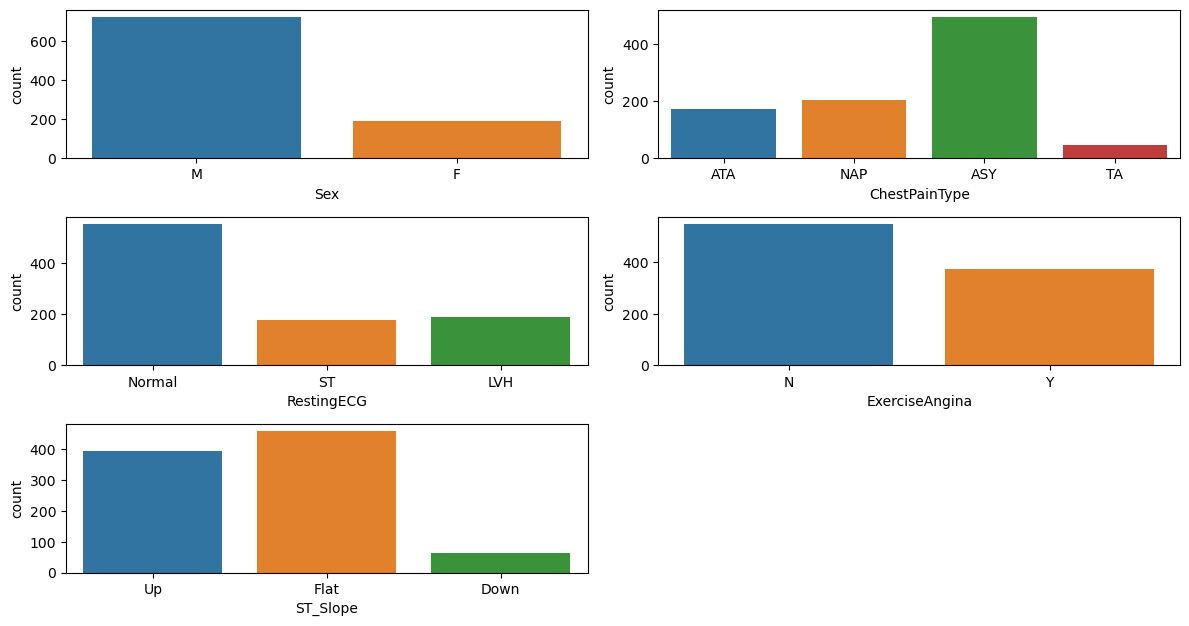

In [ ]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.select_dtypes(include='object').columns):
    plt.subplot(4, 2, i+1)
    sns.countplot(x=column, data=data)
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis:
### a. Explore relationships between pairs of numerical variables using scatter plots or pair plots.

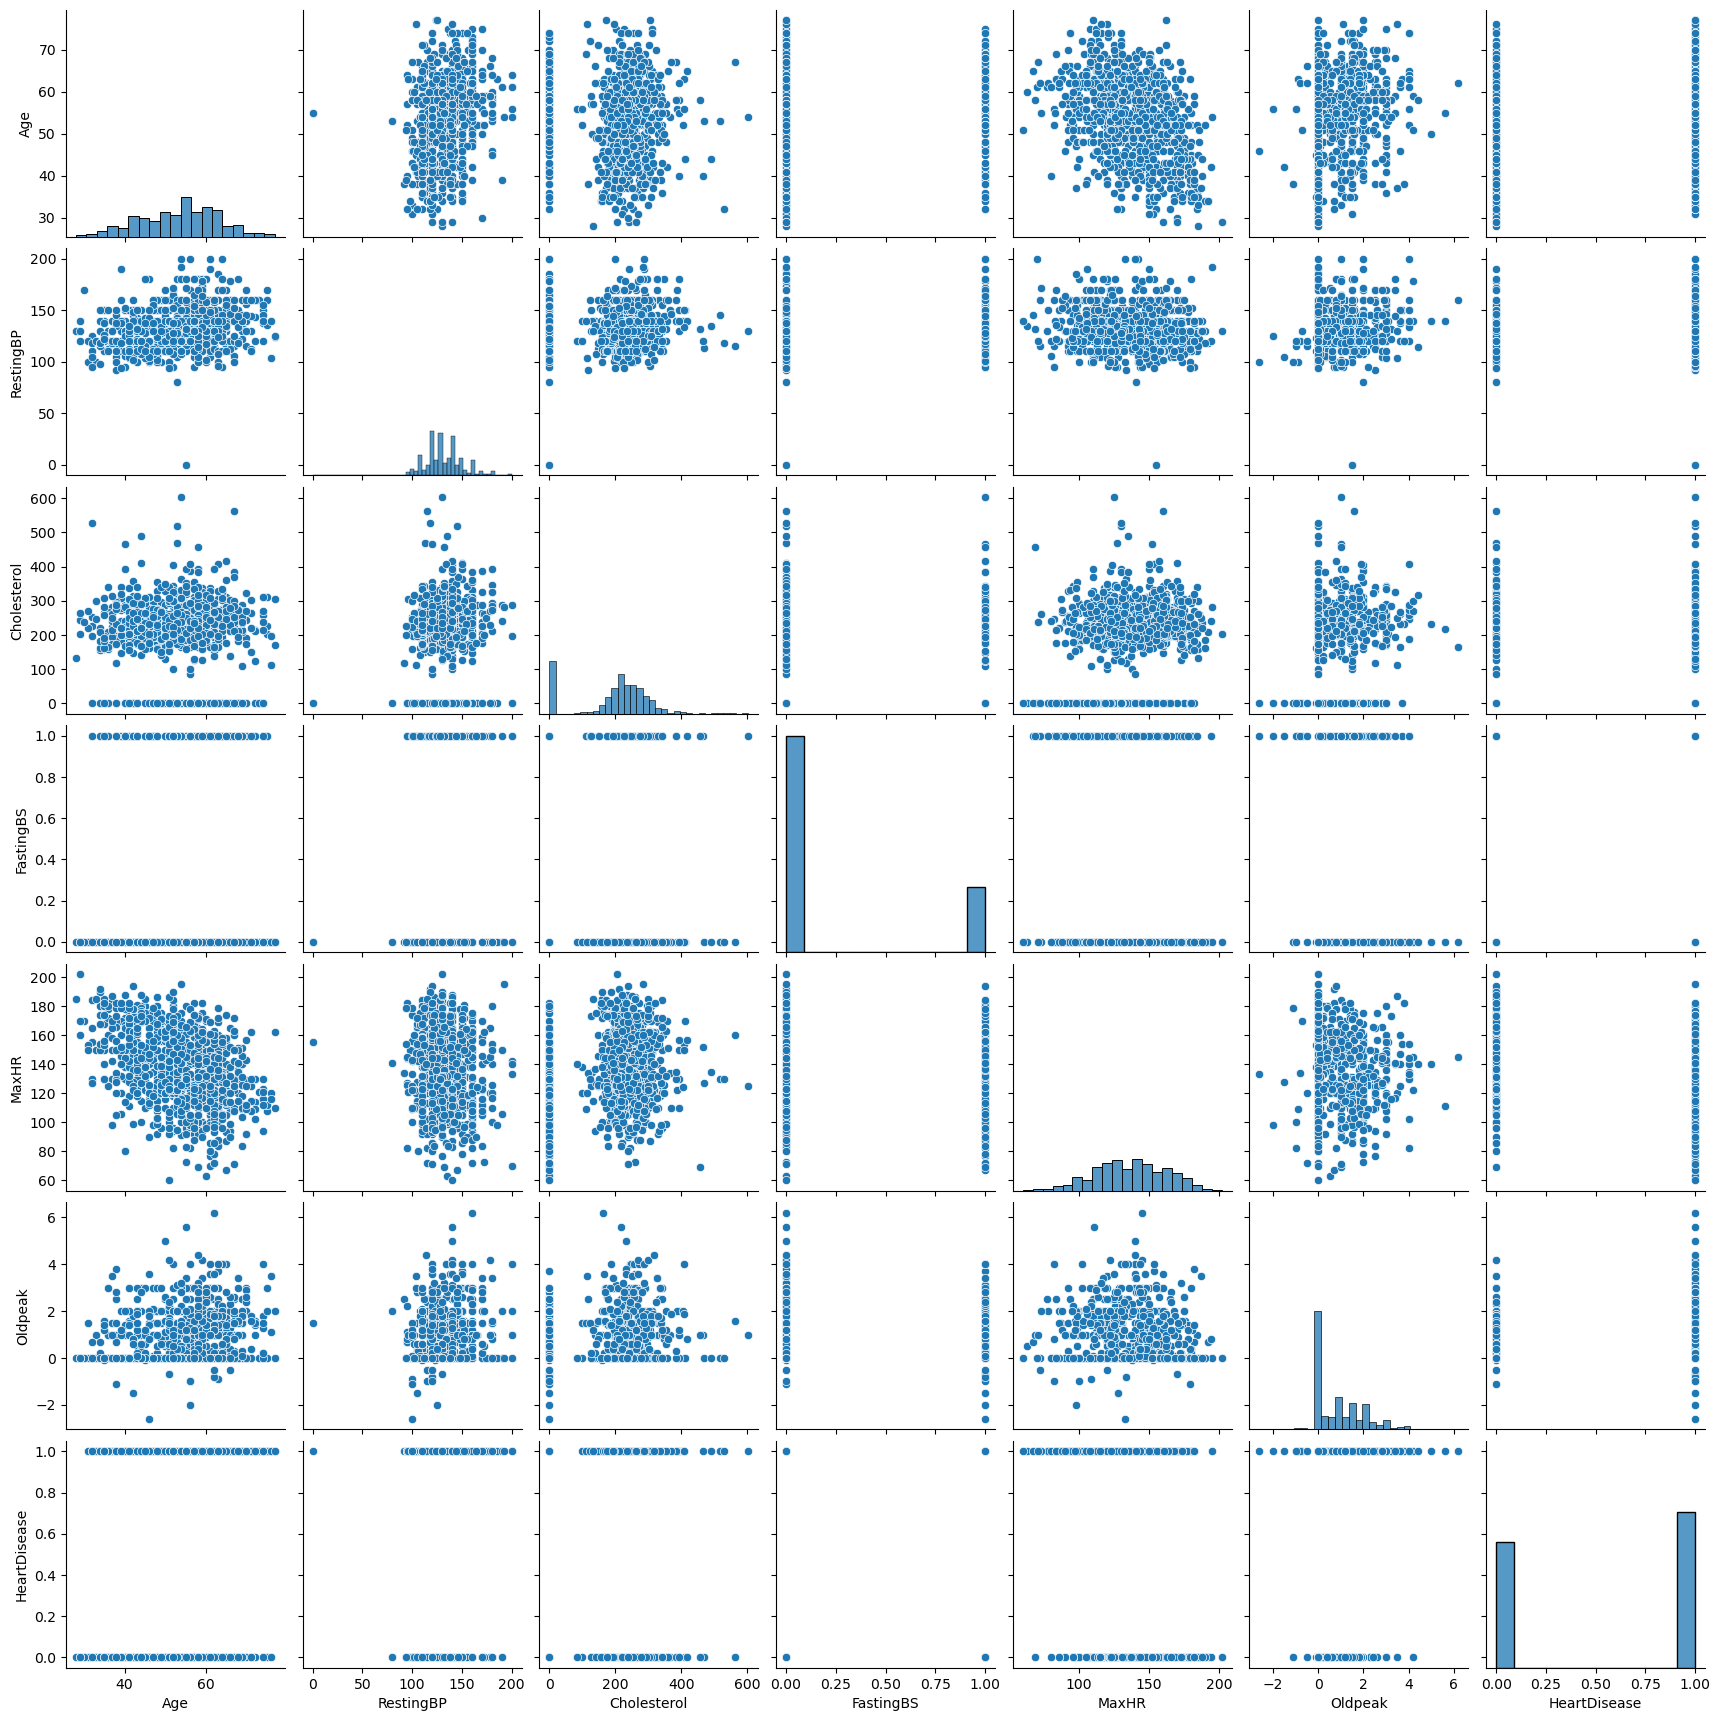

In [ ]:
sns.pairplot(data)
plt.show()

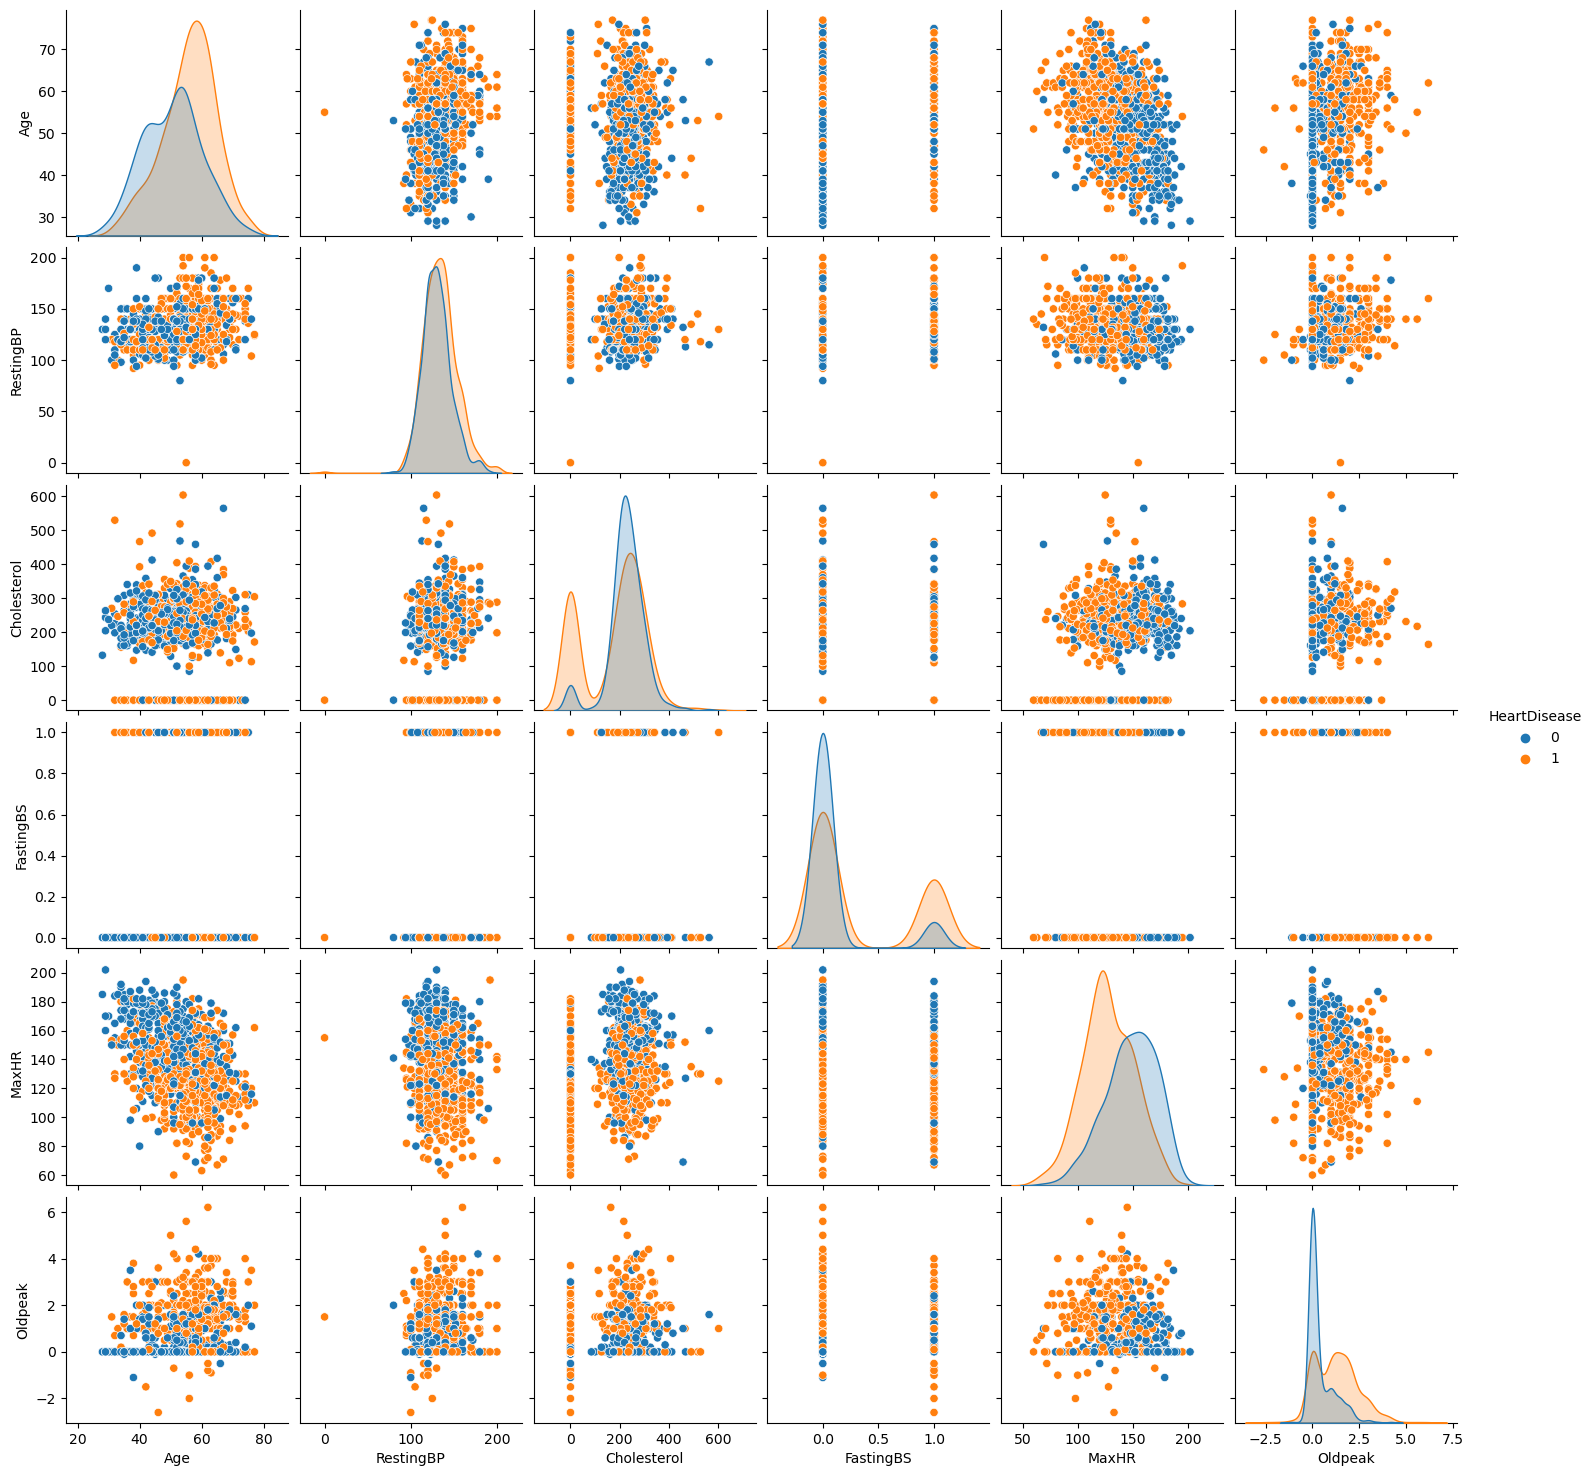

In [ ]:
sns.pairplot(data, hue='HeartDisease')

### b. Explore relationships between numerical and categorical variables using box plots or violin plots.

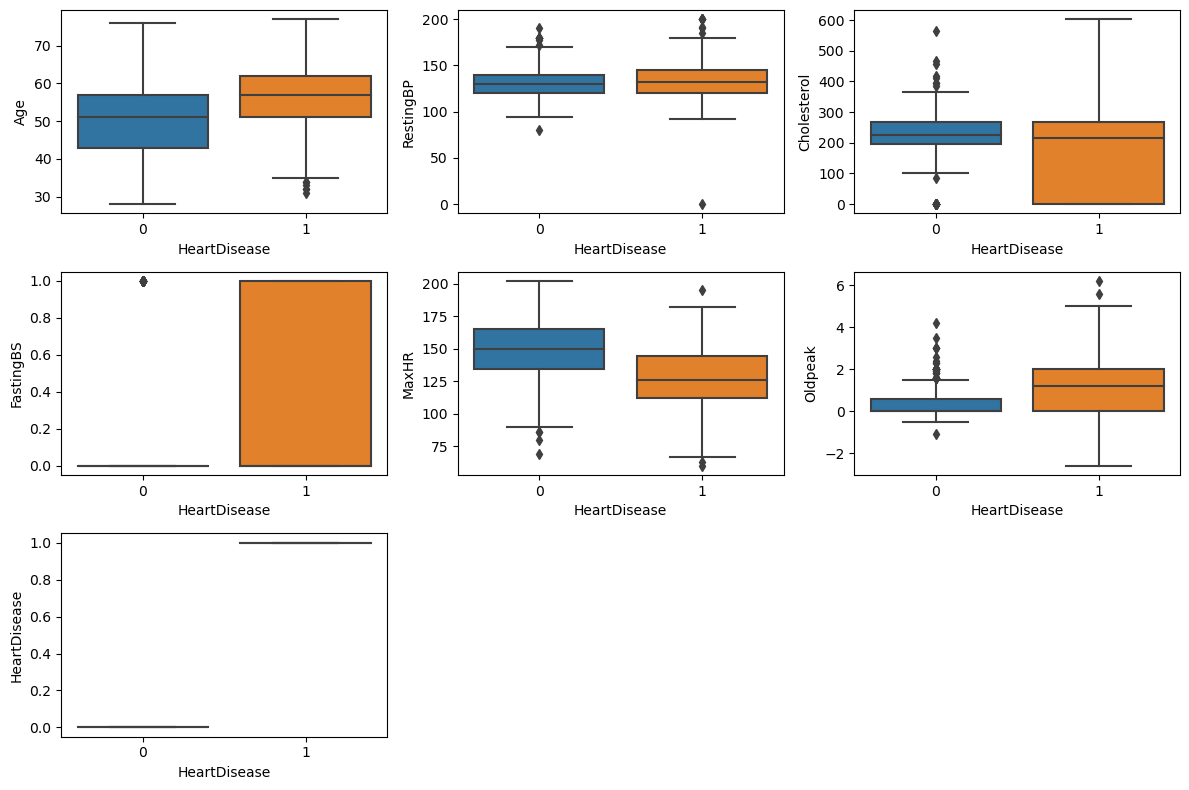

In [ ]:
plt.figure(figsize=(12, 8))
for i, column in enumerate(data.select_dtypes(include=['float64', 'int64']).columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='HeartDisease', y=column, data=data)
plt.tight_layout()
plt.show()

### c. Calculate correlation coefficients between numerical variables.

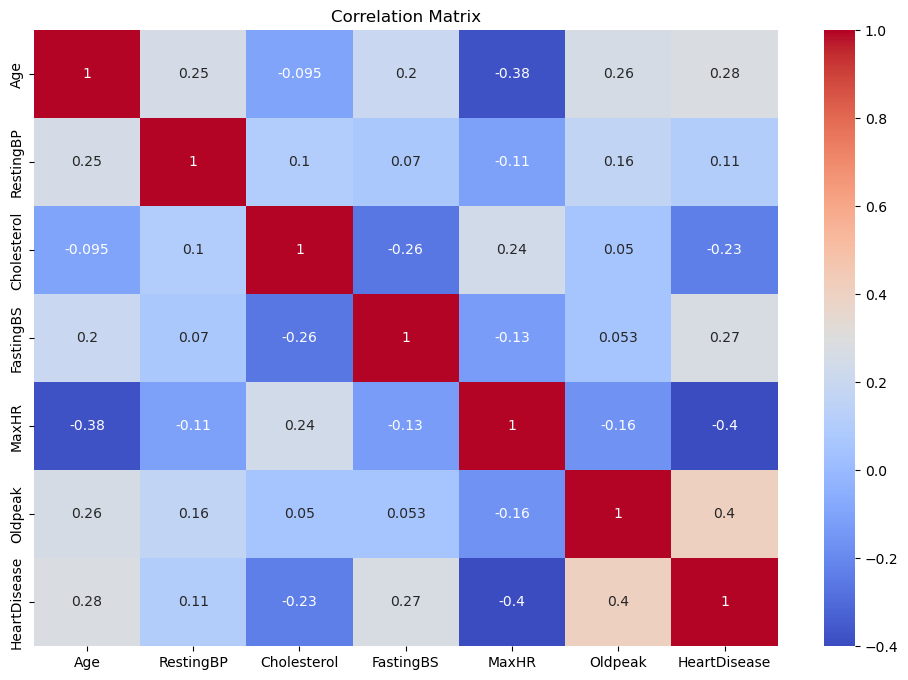

In [ ]:
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## 6) Data Preprocessing

In [ ]:
data["Sex"] = data["Sex"].replace({'M': 1, 'F': 0})

In [ ]:
data["ChestPainType"] = data["ChestPainType"].replace({'TA': 1, 'ATA': 2, 'NAP': 3, 'ASY': 4})

In [ ]:
data["RestingECG"] = data["RestingECG"].replace({'Normal': 0, 'ST': 1, 'LVH': 2})

In [ ]:
data["ExerciseAngina"] = data["Sex"].replace({'Y': 1, 'N': 0})

In [ ]:
data["ST_Slope"] = data["ST_Slope"].replace({'Up': 2, 'Flat': 1, 'Down': 0})

In [ ]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,2,140,289,0,0,172,1,0.0,2,0
1,49,0,3,160,180,0,0,156,0,1.0,1,1
2,37,1,2,130,283,0,1,98,1,0.0,2,0
3,48,0,4,138,214,0,0,108,0,1.5,1,1
4,54,1,3,150,195,0,0,122,1,0.0,2,0


In [ ]:
print(data.dtypes)

Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG          int64
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
ST_Slope            int64
HeartDisease        int64
dtype: object


In [ ]:
for i in range(data.shape[1]):
    print(data.iloc[:,i].unique())

[40 49 37 48 54 39 45 58 42 38 43 60 36 44 53 52 51 56 41 32 65 35 59 50
 47 31 46 57 55 63 66 34 33 61 29 62 28 30 74 68 72 64 69 67 73 70 77 75
 76 71]
[1 0]
[2 3 4 1]
[140 160 130 138 150 120 110 136 115 100 124 113 125 145 112 132 118 170
 142 190 135 180 108 155 128 106  92 200 122  98 105 133  95  80 137 185
 165 126 152 116   0 144 154 134 104 139 131 141 178 146 158 123 102  96
 143 172 156 114 127 101 174  94 148 117 192 129 164]
[289 180 283 214 195 339 237 208 207 284 211 164 204 234 273 196 201 248
 267 223 184 288 215 209 260 468 188 518 167 224 172 186 254 306 250 177
 227 230 294 264 259 175 318 216 340 233 205 245 194 270 213 365 342 253
 277 202 297 225 246 412 265 182 218 268 163 529 100 206 238 139 263 291
 229 307 210 329 147  85 269 275 179 392 466 129 241 255 276 282 338 160
 156 272 240 393 161 228 292 388 166 247 331 341 243 279 198 249 168 603
 159 190 185 290 212 231 222 235 320 187 266 287 404 312 251 328 285 280
 192 193 308 219 257 132 226 217 303 298 256 1

## 7) Re-arrange columns/features
#### No re-arrangement needed

## 8) Separate the features (X) and the target variable (y).

In [ ]:
X = data.drop('HeartDisease',axis=1)
y = data['HeartDisease']

## 9) Perform Standardization or normalization on the features as required.

In [ ]:
X = StandardScaler().fit_transform(X)

## 10) Split the dataset into training and testing sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size = 0.2, random_state=42)

## 11) Implement Multilayer Perceptron (MLP) Classifier

### a. Model minimum four classifiers and observe the accuracy of each

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

classifiers = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier()
}

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy:", accuracy)

Logistic Regression Accuracy: 0.8380952380952381
Decision Tree Accuracy: 0.7727891156462585
SVM Accuracy: 0.8394557823129252


C:\Users\Admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


KNN Accuracy: 0.8081632653061225


### b. Model Voting Classifier with both Hard Voting and Soft Voting and observe the accuracy

In [ ]:
voting_clf_hard = VotingClassifier(estimators=list(classifiers.items()), voting='hard')
voting_clf_hard.fit(X_train, y_train)
y_pred_hard = voting_clf_hard.predict(X_test)
accuracy_hard = accuracy_score(y_test, y_pred_hard)
print("\nVoting Classifier (Hard) Accuracy:", accuracy_hard)

voting_clf_soft = VotingClassifier(estimators=list(classifiers.items()), voting='soft')
voting_clf_soft.fit(X_train, y_train)
y_pred_soft = voting_clf_soft.predict(X_test)
accuracy_soft = accuracy_score(y_test, y_pred_soft)
print("Voting Classifier (Soft) Accuracy:", accuracy_soft)

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)



Voting Classifier (Hard) Accuracy: 0.8217687074829932
Voting Classifier (Soft) Accuracy: 0.8272108843537415


### c. Model any one Bagging method (for ex. Random Forest / Decision Trees) and observe the accuracy

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("\nRandom Forest Accuracy:", accuracy_rf)


Random Forest Accuracy: 0.854421768707483


### d. Model any one Boosting method (for ex. AdaBoost)

In [ ]:
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
adaboost.fit(X_train, y_train)
y_pred_ab = adaboost.predict(X_test)
accuracy_ab = accuracy_score(y_test, y_pred_ab)
print("AdaBoost Accuracy:", accuracy_ab)

AdaBoost Accuracy: 0.8095238095238095


### e. Evaluate the performance of the trained model using appropriate metrics.

In [ ]:
# Evaluation metrics for each classifier
for name, clf in classifiers.items():
    y_pred = clf.predict(X_test)
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"{name} Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       319
           1       0.90      0.81      0.85       416

    accuracy                           0.84       735
   macro avg       0.84      0.84      0.84       735
weighted avg       0.85      0.84      0.84       735

Logistic Regression Confusion Matrix:
[[281  38]
 [ 81 335]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.84      0.76       319
           1       0.85      0.72      0.78       416

    accuracy                           0.77       735
   macro avg       0.78      0.78      0.77       735
weighted avg       0.79      0.77      0.77       735

Decision Tree Confusion Matrix:
[[268  51]
 [116 300]]

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       319
           

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


### f. Display the classification report for all the classifiers and confusion matrix.

In [ ]:

# Evaluation metrics for Voting Classifier with Hard Voting
print("\nVoting Classifier (Hard) Classification Report:")
print(classification_report(y_test, y_pred_hard))
print("Voting Classifier (Hard) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_hard))

# Evaluation metrics for Voting Classifier with Soft Voting
print("\nVoting Classifier (Soft) Classification Report:")
print(classification_report(y_test, y_pred_soft))
print("Voting Classifier (Soft) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_soft))

# Evaluation metrics for Bagging method (Random Forest)
print("\nBagging (Random Forest) Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Bagging (Random Forest) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Evaluation metrics for Boosting method (AdaBoost)
print("\nBoosting (AdaBoost) Classification Report:")
print(classification_report(y_test, y_pred_ab))
print("Boosting (AdaBoost) Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ab))


Voting Classifier (Hard) Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81       319
           1       0.89      0.78      0.83       416

    accuracy                           0.82       735
   macro avg       0.82      0.83      0.82       735
weighted avg       0.83      0.82      0.82       735

Voting Classifier (Hard) Confusion Matrix:
[[281  38]
 [ 93 323]]

Voting Classifier (Soft) Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       319
           1       0.89      0.79      0.84       416

    accuracy                           0.83       735
   macro avg       0.83      0.83      0.83       735
weighted avg       0.83      0.83      0.83       735

Voting Classifier (Soft) Confusion Matrix:
[[278  41]
 [ 86 330]]

Bagging (Random Forest) Classification Report:
              precision    recall  f1-score   support

           0 